# Accessing and Visualizing EIS Waveform Data

This example demonstrates how to access the raw waveform data captured during an Electrochemical Impedance Spectroscopy (EIS) measurement using the [zahner_link](https://doc.zahner.de/im7/apis/zahner_link/python/) library.

In EIS, the system applies a sinusoidal voltage or current perturbation at different frequencies and measures the response. While impedance is typically presented as magnitude and phase values across frequencies, the raw waveform data can provide valuable additional insights about your system's behavior.

In this notebook, you'll learn how to:

1. Connect to an IM7 electrochemical workstation
2. Set up and run a basic EIS measurement with [EisGenerateJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisGenerateJob)
3. Access the raw waveform data for specific frequencies using [get_waves()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.PathData.get_waves)
4. Visualize the voltage and current waveforms using matplotlib
5. Create phase plots showing the relationship between voltage and current signals

This type of analysis can be useful for:
- Detecting non-linearities in your electrochemical system
- Identifying measurement artifacts or noise sources
- Validating the quality of your EIS data collection
- Educational purposes to better understand the relationship between time-domain signals and frequency-domain impedance

It is very important to note that impedance cannot be calculated directly from the waves. To do this, the complex calibration algorithms for the entire signal chain would have to be applied, which the measuring device performs internally to calculate the impedance. The wave represents the modulation of the converters and is only used to estimate the signal shape, whether it is distorted or noisy, or whether other artifacts are visible.

Let's start by importing the necessary libraries and connecting to the IM7 potentiostat.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter, PercentFormatter
from typing import Union
import zahner_link as zl

link = zl.ZahnerLinkExc("169.254.9.137", "1994")
status = link.connect()

if status == zl.ZahnerLinkServiceStatusEnum.SUCCESS_NO_ERROR:
    print("Connected successfully")
else:
    print(f"Failed to connect, status: {status}")

switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")
link.do_job(switch_on_job)

Connected successfully


True

## Perform an EIS Measurement

Now let's run an EIS measurement using the [EisGenerateJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisGenerateJob) class. We'll configure it to measure impedance at frequencies from 10 Hz to 10 kHz, with a relatively large amplitude to ensure a good signal-to-noise ratio for our waveform analysis.

To ensure we get good waveform data, we'll set the measurement parameters to record multiple periods at each frequency.

In [2]:
eis_job = zl.meas.EisGenerateJob(
    bias=0,  # 0V DC bias
    min_frequency=1,  # Lowest frequency: 1 Hz
    max_frequency=100e3,  # Highest frequency: 100 kHz
    start_frequency=1000,  # Start at 1 kHz
    points_per_decade_upper=8,  # 8 points per decade above 66 Hz
    points_per_decade_lower=5,  # 5 points per decade below 66 Hz
    pre_duration=0.1,  # Short pre-conditioning time
    pre_waves=1,  # 1 wave for pre-conditioning
    meas_duration=0.1,  # Measure for at least 1 second
    meas_waves=5,  # Measure at least 5 complete waves at each frequency
    amplitude=0.02,  # 20 mV amplitude
)

link.do_job(eis_job)

True

## Plotting the Standard Bode Plot

Before diving into the waveform data, let's first look at the traditional EIS representation - a Bode plot showing magnitude and phase of the impedance vs. frequency.

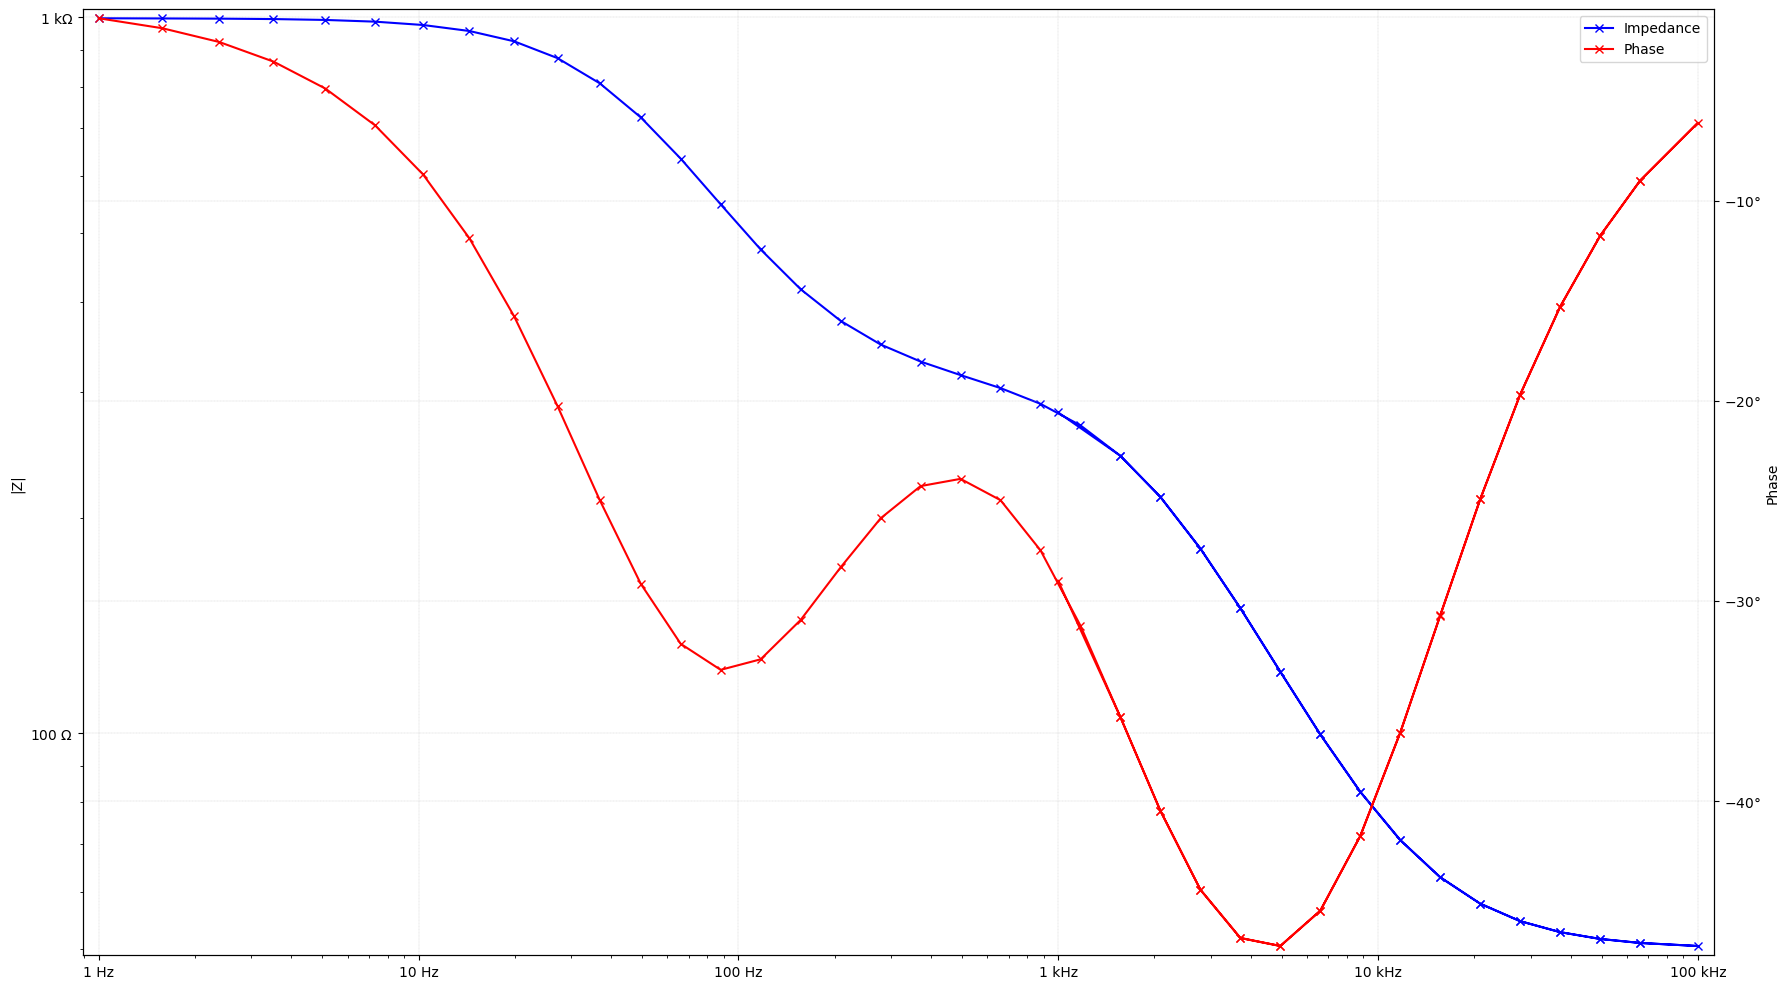

In [3]:
def plot_spectra(data: zl.EisDataset):
    frequencies = data.get_frequencies()
    impedances = data.get_impedance_data().get_calculated_complex_impedance_track()
    fig, (impedance_ax) = plt.subplots(
        1,
        1,
    )
    phase_ax = impedance_ax.twinx()

    (impedance_line,) = impedance_ax.loglog(
        frequencies,
        np.absolute(impedances),
        marker="x",
        color="blue",
        label="Impedance",
    )

    (phase_line,) = phase_ax.semilogx(
        frequencies,
        np.angle(impedances, deg=True),
        marker="x",
        color="red",
        label="Phase",
    )

    impedance_ax.yaxis.set_major_formatter(EngFormatter(unit=r"$\Omega$"))
    impedance_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    impedance_ax.set_ylabel(r"|Z|")
    impedance_ax.grid(linestyle="dashed", linewidth=0.2)
    margin = 0.01
    impedance_ax.margins(margin)

    phase_ax.yaxis.set_major_formatter(EngFormatter(unit="$°$", sep=""))
    phase_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    phase_ax.set_ylabel("Phase")
    phase_ax.grid(linestyle="dashed", linewidth=0.2)
    phase_ax.margins(margin)
    impedance_ax.legend(handles=[impedance_line, phase_line])

    fig.set_size_inches(18, 10)
    fig.tight_layout()
    plt.show()

eis_data = link.get_job_result_data(eis_job)
plot_spectra(eis_data)

## Accessing the Data

Now let's extract the raw waveform data for a specific frequency point. The IM7 captures the raw voltage and current waveforms during the measurement, which can be accessed using the [get_waves](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.PathData.get_waves) method. 

[get_waves](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.PathData.get_waves) returns an array containing one wave for each frequency point. Therefore, the available frequencies are printed first in the following:

In [4]:
frequencies = eis_data.get_frequencies()
print("Measured frequencies:")
for i, freq in enumerate(frequencies):
    print(f"Point {i}: {freq:.2f} Hz")

Measured frequencies:
Point 0: 1000.00 Hz
Point 1: 1565.11 Hz
Point 2: 2087.10 Hz
Point 3: 2783.20 Hz
Point 4: 3711.45 Hz
Point 5: 4949.30 Hz
Point 6: 6600.00 Hz
Point 7: 8801.24 Hz
Point 8: 11736.64 Hz
Point 9: 15651.07 Hz
Point 10: 20871.03 Hz
Point 11: 27831.97 Hz
Point 12: 37114.53 Hz
Point 13: 49493.02 Hz
Point 14: 66000.00 Hz
Point 15: 100000.00 Hz
Point 16: 66000.00 Hz
Point 17: 49493.02 Hz
Point 18: 37114.53 Hz
Point 19: 27831.97 Hz
Point 20: 20871.03 Hz
Point 21: 15651.07 Hz
Point 22: 11736.64 Hz
Point 23: 8801.24 Hz
Point 24: 6600.00 Hz
Point 25: 4949.30 Hz
Point 26: 3711.45 Hz
Point 27: 2783.20 Hz
Point 28: 2087.10 Hz
Point 29: 1565.11 Hz
Point 30: 1173.66 Hz
Point 31: 880.12 Hz
Point 32: 660.00 Hz
Point 33: 494.93 Hz
Point 34: 371.15 Hz
Point 35: 278.32 Hz
Point 36: 208.71 Hz
Point 37: 156.51 Hz
Point 38: 117.37 Hz
Point 39: 88.01 Hz
Point 40: 66.00 Hz
Point 41: 49.49 Hz
Point 42: 36.83 Hz
Point 43: 27.19 Hz
Point 44: 19.89 Hz
Point 45: 14.41 Hz
Point 46: 10.32 Hz
Point 47:

## Plotting Waveforms for a Single Frequency

Let's define a function to extract and plot the voltage and current waveforms for a given frequency point. We'll show how the two signals relate to each other in both time-domain and as a phase plot.

Access the wave as shown in the following code snippet:

```python
eis_data.get_path_data("voltage").get_waves()[frequency_index]
```

`frequency_index` is necessary because the wave is a two-dimensional array, with one wave corresponding to each frequency point.

The wave contains 256 support points and the measurement data for all periods was averaged into one wave.
The unit of the wave is the level of the analog-to-digital converter.

In [5]:
def plot_waveforms(eis_data: zl.EisDataset, frequency_index):
    """Plot time-domain waveforms and phase plot for a specific frequency measurement."""
    frequencies = eis_data.get_frequencies()
    freq = frequencies[frequency_index]
    
    # Get voltage and current waveforms
    voltage_wave = np.array(eis_data.get_path_data("voltage").get_waves()[frequency_index])
    current_wave = np.array(eis_data.get_path_data("current").get_waves()[frequency_index])
    
    # Time points (assuming equal sampling)
    sample_period = 1.0 / (freq * 256)
    time = np.arange(0, len(voltage_wave) * sample_period, sample_period)
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Time-domain plot
    ax1_twin = ax1.twinx()
    
    voltage_line = ax1.plot(time, voltage_wave, 'b-', label='Voltage')
    current_line = ax1_twin.plot(time, current_wave, 'r-', label='Current')
    
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Voltage')
    ax1_twin.set_ylabel('Current')
    ax1.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax1_twin.yaxis.set_major_formatter(PercentFormatter(1.0))
    freqFormat = EngFormatter(unit="Hz")
    ax1.set_title(f'Waveforms at {freqFormat.format_eng(freq)}')
    
    # Add lines from both axes to the legend
    lines = voltage_line + current_line
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right')
    ax1.grid(True)
    
    # Phase plot (voltage vs current)
    ax2.plot(voltage_wave, current_wave, 'g-', label='V-I relationship')
    ax2.set_xlabel('Voltage')
    ax2.set_ylabel('Current')
    ax2.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    ax2.set_title(f'Lissajous curve at {freqFormat.format_eng(freq)}')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Return both the voltage and current waveforms
    return voltage_wave, current_wave

Now let's pick a frequency index from our measurement and visualize its waveforms:

Analyzing waveforms at 3711.45 Hz


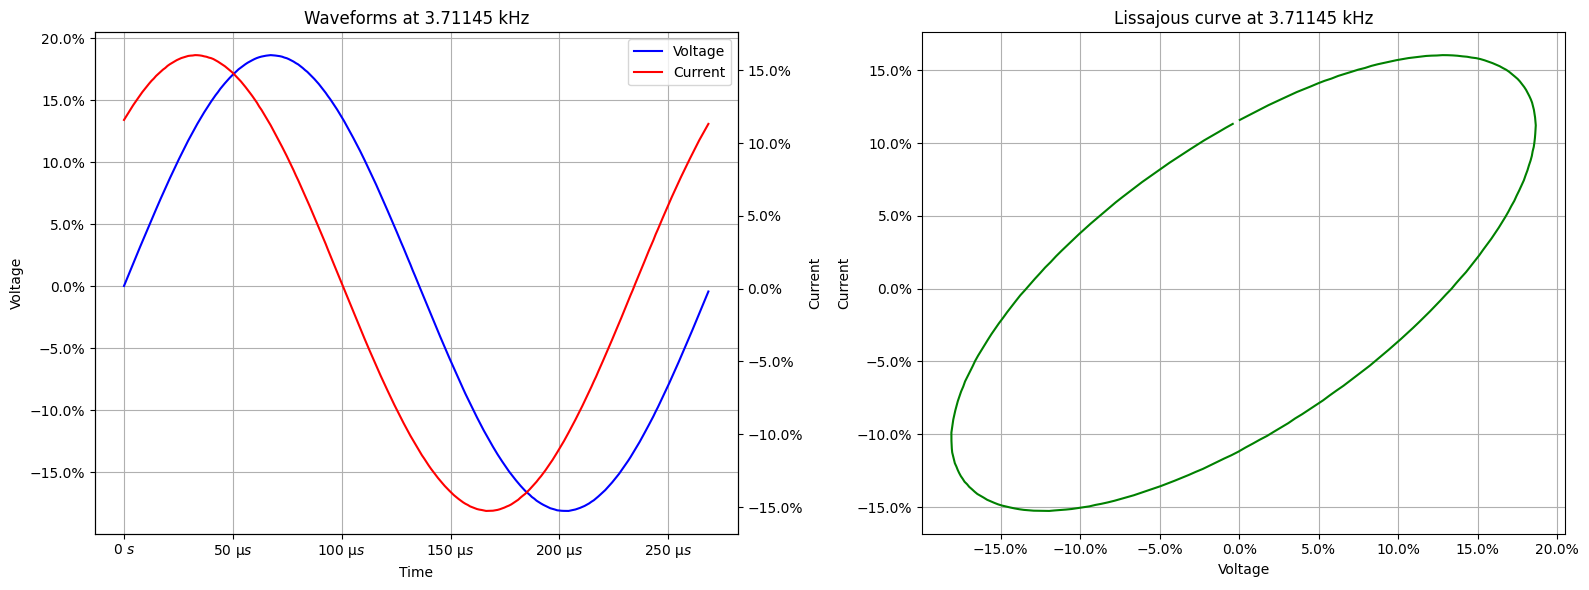

In [6]:
selected_freq_index = len(frequencies) // 2

print(f"Analyzing waveforms at {frequencies[selected_freq_index]:.2f} Hz")
voltage_wave, current_wave = plot_waveforms(eis_data, selected_freq_index)

## Analyzing Different Frequencies

Let's also look at a lower frequency, where the phase relationship might be different:

Analyzing waveforms at 1000.00 Hz


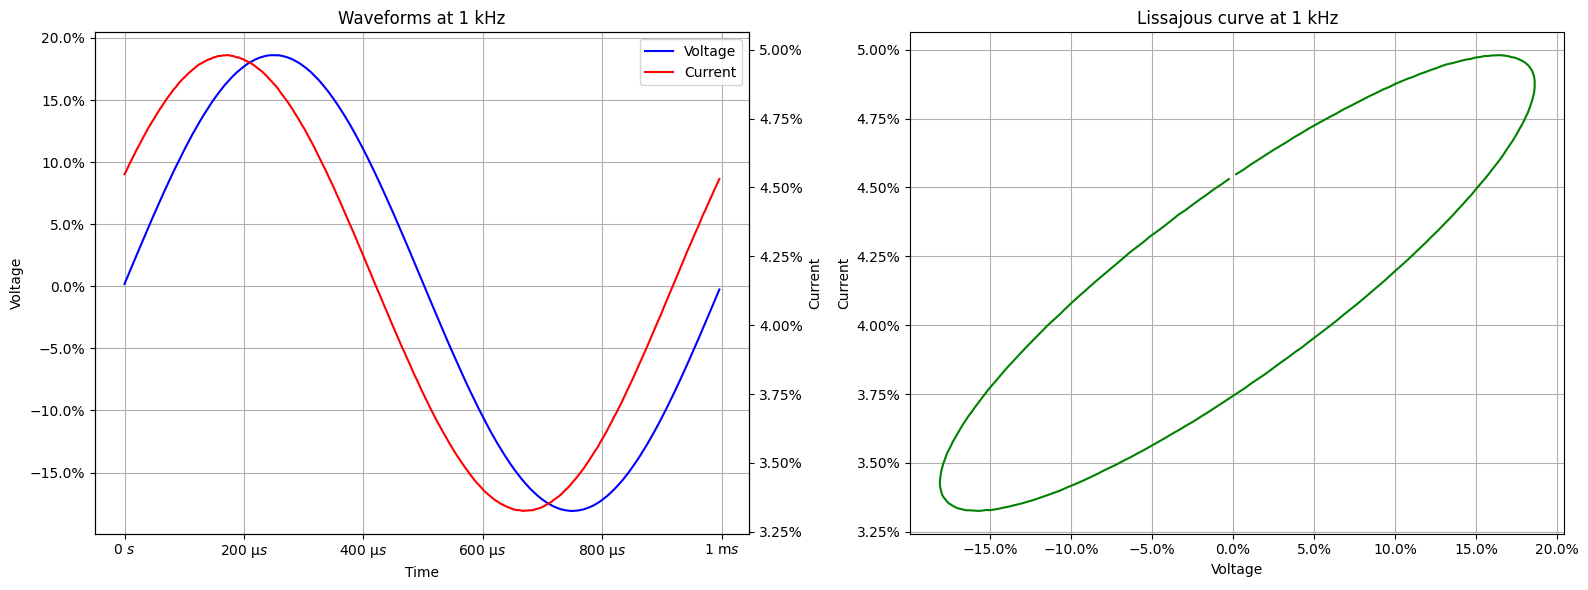

In [7]:
low_freq_index = 0

print(f"Analyzing waveforms at {frequencies[low_freq_index]:.2f} Hz")
voltage_wave_low, current_wave_low = plot_waveforms(eis_data, low_freq_index)

## Analyzing a Lower Frequency

Now let's examine a lower frequency point:

Analyzing waveforms at 1.00 Hz


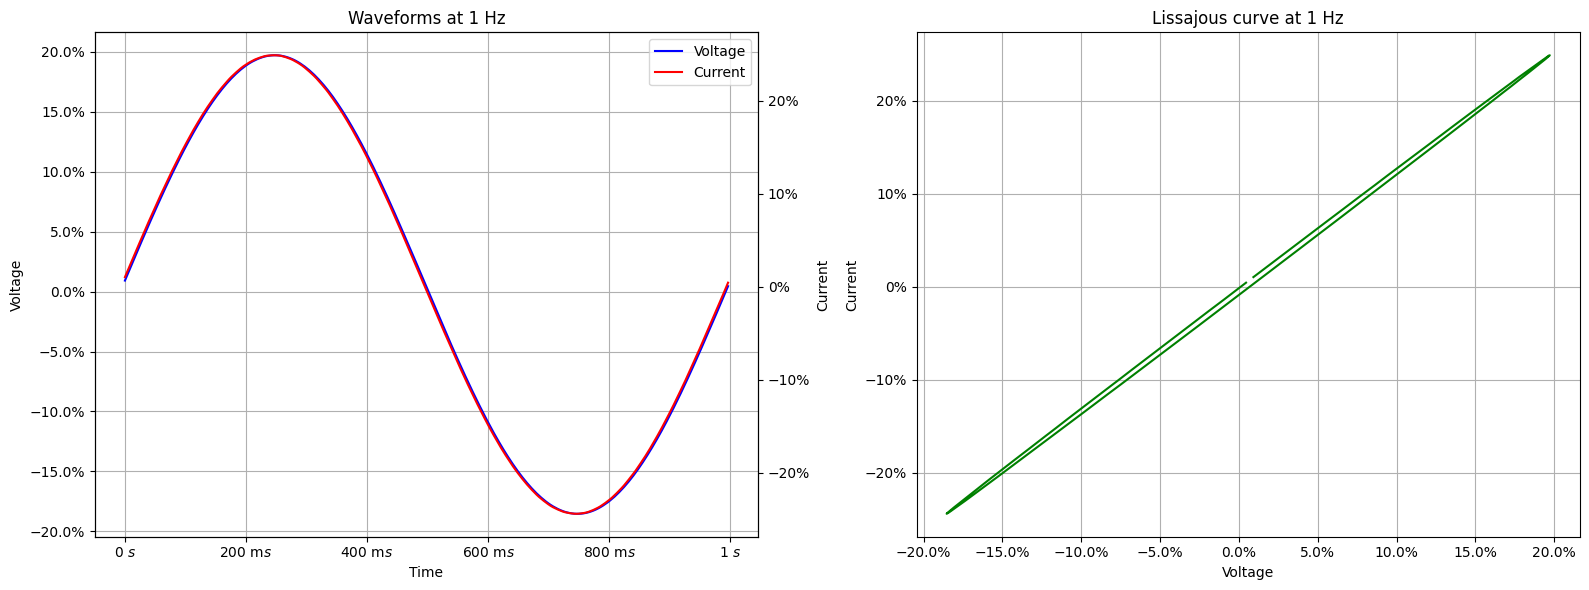

In [8]:
high_freq_index = len(frequencies) - 1

print(f"Analyzing waveforms at {frequencies[high_freq_index]:.2f} Hz")
voltage_wave_high, current_wave_high = plot_waveforms(eis_data, high_freq_index)

## Comparing Phase Relationships Across Frequencies

Let's create a visualization that compares the phase relationships between voltage and current at different frequencies. The Waves are normalized, that they amplitude of current and voltage is equal in each plot, that the phase difference can be seen better.

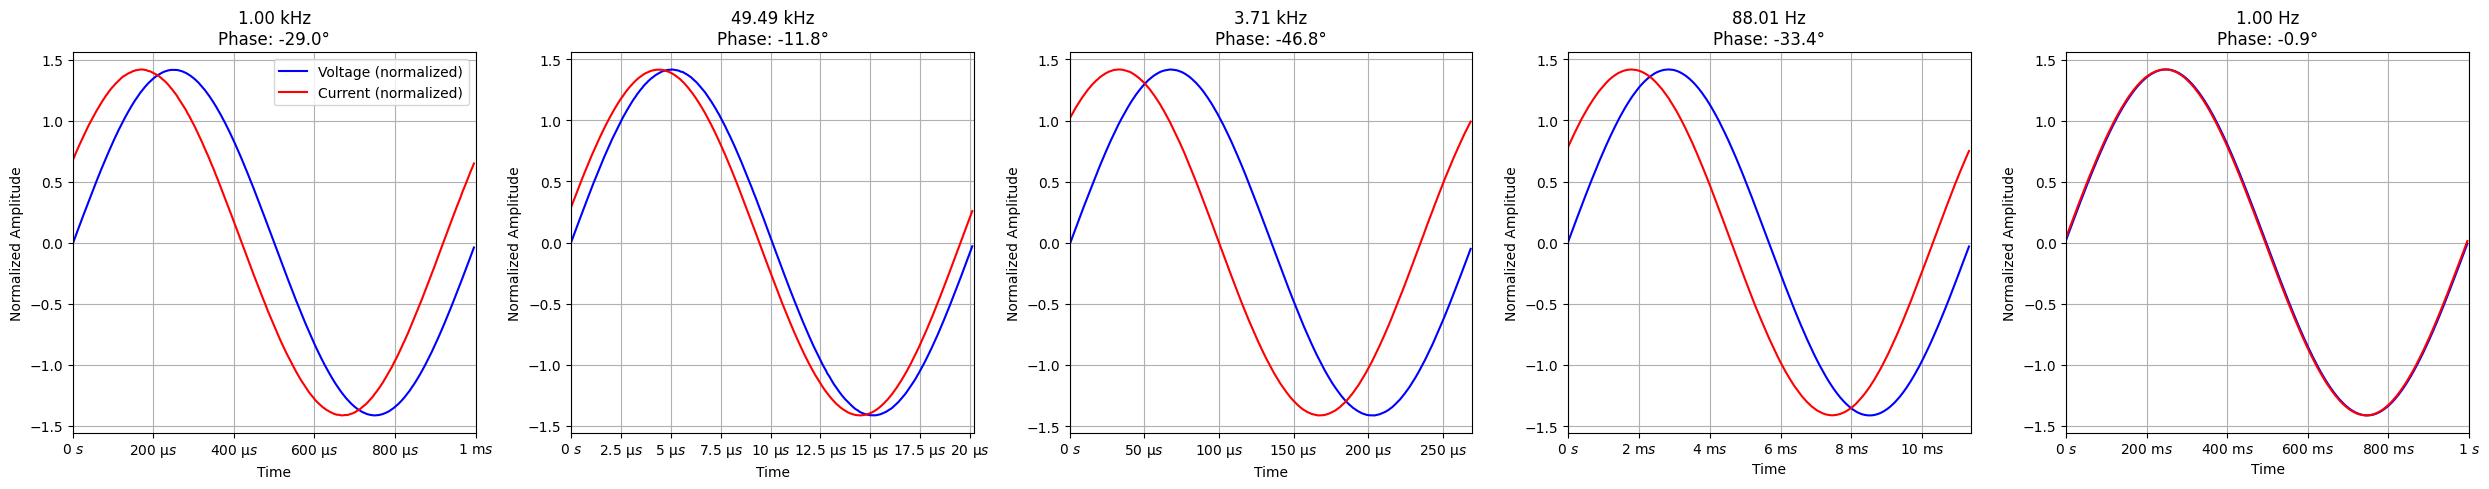

In [9]:
def compare_phase_relationships(eis_data:zl.EisDataset, freq_indices):
    """Compare phase relationships between voltage and current at multiple frequencies."""
    frequencies = eis_data.get_frequencies()
    
    fig, axes = plt.subplots(1, len(freq_indices), figsize=(5*len(freq_indices), 5))
    
    if len(freq_indices) == 1:
        axes = [axes]  # Make axes iterable if there's only one subplot
    
    for i, idx in enumerate(freq_indices):
        freq = frequencies[idx]
        
        # Get waveforms
        voltage_wave = np.array(eis_data.get_path_data("voltage").get_waves()[idx])
        current_wave = np.array(eis_data.get_path_data("current").get_waves()[idx])
        
        # Normalize the waveforms to better compare shapes
        voltage_norm = (voltage_wave - np.mean(voltage_wave)) / np.std(voltage_wave)
        current_norm = (current_wave - np.mean(current_wave)) / np.std(current_wave)
        
        sample_period = 1.0 / (freq * 256)
        time = np.arange(0, len(voltage_wave) * sample_period, sample_period)
        
        axes[i].plot(time, voltage_norm, 'b-', label='Voltage (normalized)')
        axes[i].plot(time, current_norm, 'r-', label='Current (normalized)')
        
        # Get impedance phase angle
        z = eis_data.get_impedance_data().get_calculated_complex_impedance_track()[idx]
        phase = np.angle(z, deg=True)
        
        freqFormat = EngFormatter(unit="Hz",places=2)
        axes[i].set_title(f'{freqFormat.format_eng(freq)}\nPhase: {phase:.1f}°')
        axes[i].set_xlabel('Time')
        axes[i].xaxis.set_major_formatter(EngFormatter(unit="$s$"))
        axes[i].set_ylabel('Normalized Amplitude')
        axes[i].grid(True)
        
        if len(time) > 0:
            period = 1.0 / freq
            axes[i].set_xlim(0, period)
            
        if i == 0:
            axes[i].legend()
    
    plt.tight_layout()
    plt.show()

# Compare a few frequencies across the spectrum
# High frequency (index 0), mid frequency (middle index), and low frequency (highest index)
indices_to_compare = [0, int(len(frequencies)*0.25), int(len(frequencies)*0.5), int(len(frequencies)*0.75), len(frequencies)-1]  # High, mid, low frequencies
compare_phase_relationships(eis_data, indices_to_compare)

## Switch Off and Disconnect

Let's properly shut down the potentiostat and disconnect from the IM7.

In [10]:
link.do_job(switch_off_job)
link.disconnect()